# Bloc 03 - The North Face ecommerce

## 03 - Topic modeling

## Import librairies

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wordcloud
from IPython.display import Image, display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
data = pd.read_csv("../data/data_cleaned.csv")

vectorizer = TfidfVectorizer(max_df=0.99, min_df=0.01)
X = vectorizer.fit_transform(data["description_cleaned"])

In [7]:
nb_topics = 10
svd_model = TruncatedSVD(n_components=nb_topics, n_iter=100, random_state=42)
lsa = svd_model.fit_transform(X)

topic_encoded_df = pd.DataFrame(lsa, columns = [f"topic_{i}" for i in range(nb_topics)])
topic_encoded_df["documents"] = data['description_cleaned']
topic_encoded_df

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,documents
0,0.224810,-0.031135,0.032777,0.116350,-0.047644,-0.039056,0.017692,-0.052633,-0.005239,-0.062382,active classic boxer s reason boxer cult favor...
1,0.207781,-0.059567,0.067246,0.104768,-0.061074,0.040427,-0.015499,-0.067768,0.057443,-0.004127,active sport boxer brief skin glory require mo...
2,0.203222,-0.064548,0.074029,0.058892,-0.050554,0.114893,0.001524,-0.022258,-0.007549,-0.039434,active sport brief superbreathable nofly brief...
3,0.276457,-0.173248,-0.056714,-0.082099,0.024871,-0.101135,-0.009996,0.061765,0.288833,-0.035851,alpine guide pant skin climb ice switch rock t...
4,0.279482,-0.166809,0.065437,-0.243380,-0.038697,-0.056578,0.018153,0.118312,0.122740,0.091123,alpine wind jkt high ridge steep ice alpine ja...
...,...,...,...,...,...,...,...,...,...,...,...
495,0.318597,-0.091362,0.245614,0.109963,-0.339991,-0.091742,-0.007098,-0.183512,0.124332,-0.192402,cap cut loose madden crowd search undone capil...
496,0.321961,-0.068632,0.392740,0.064449,-0.306714,-0.045373,0.005330,-0.155693,0.014059,-0.129864,cap crew crew edge fickle weather clearing con...
497,0.294031,-0.165088,0.080700,-0.170723,-0.022864,-0.030270,-0.002370,0.123267,0.030483,-0.016922,alltime shell need use morning time umbrella a...
498,0.270219,-0.041889,-0.180968,0.223861,0.018675,-0.172733,-0.034320,-0.066512,-0.055591,-0.015330,allwear cargo short allwear cargo short bask g...


In [8]:
def get_topic_terms(V, terms, n_top_terms):
    '''
    Retrieve n_top_terms terms associated with our truncated SVD topics.

    V (numpy.ndarray): V* matrix of our SVD of shape (topics, terms)
    terms (list): List of terms used in our SVD
    n_top_terms (int): Amount of terms to return per topic

    Output (numpy.ndarray(numpy.ndarray)): Array of arrays, top terms by topics
    '''

    top_topic_terms = []
    # For each topic vector in our right singular vectors of shape (topics, terms)
    for topic_vec in V:
        # Get sorted term indices, in ascending order, limited to top terms
        indices = np.argsort(topic_vec)[::-1]
        word_freq = {terms[i]: abs(topic_vec[i]) for i in indices[:n_top_terms]}

        top_topic_terms.append(word_freq)
        
    return top_topic_terms

topic_terms = get_topic_terms(svd_model.components_, vectorizer.get_feature_names_out(), 10)

for topic, terms in enumerate(topic_terms):
    print(f"Key terms for topic {topic+1} are {list(terms.keys())}")

Key terms for topic 1 are ['pocket', 'recycle', 'tshirt', 'recyclable', 'program', 'thread', 'common', 'organic', 'short', 'cotton']
Key terms for topic 2 are ['tshirt', 'ringspun', 'ink', 'phthalatefree', 'pvc', 'tap', 'organic', 'cotton', 'print', 'tee']
Key terms for topic 3 are ['merino', 'dry', 'odor', 'layer', 'temperature', 'beneath', 'control', 'warm', 'cap', 'gladiodor']
Key terms for topic 4 are ['merino', 'short', 'inseam', 'pant', 'size', 'organic', 'cotton', 'long', 'button', 'regular']
Key terms for topic 5 are ['merino', 'wool', 'temperature', 'machinewash', 'slowwash', 'lie', 'regulate', 'away', 'resist', 'body']
Key terms for topic 6 are ['spandex', 'blend', 'coverage', 'btm', 'line', 'nylon', 'solid', 'hip', 'scoop', 'print']
Key terms for topic 7 are ['photo', 'outside', 'poster', 'far', 'wall', 'exclusively', 'excited', 'outdoor', 'passion', 'tribute']
Key terms for topic 8 are ['shirt', 'organic', 'fleece', 'cuff', 'hem', 'cotton', 'jacket', 'handwarmer', 'jkt', 'd

Topic 0 {'pocket': np.float64(0.19523673713087214), 'recycle': np.float64(0.18750970569635966), 'tshirt': np.float64(0.1664265697922132), 'recyclable': np.float64(0.16458964636118767), 'program': np.float64(0.16236553686533514), 'thread': np.float64(0.1623515540432221), 'common': np.float64(0.16230598282240963), 'organic': np.float64(0.15440682661162863), 'short': np.float64(0.15242254565151592), 'cotton': np.float64(0.14462607048961368)}


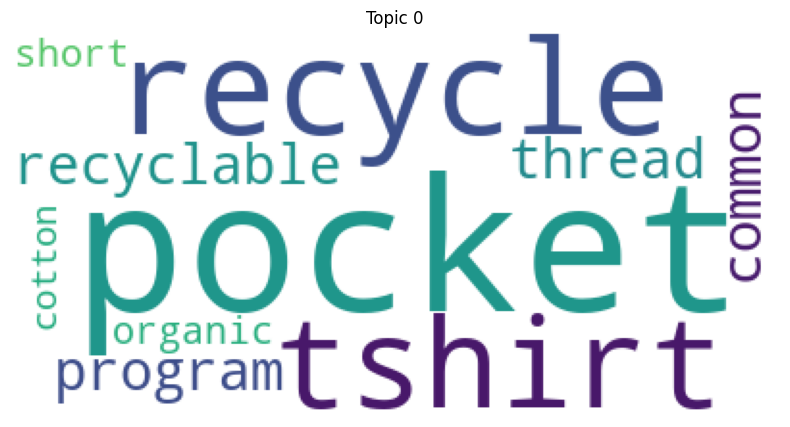

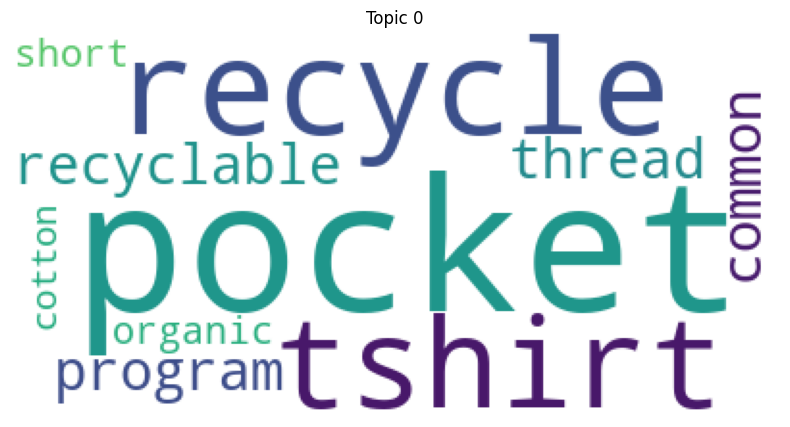

Topic 1 {'tshirt': np.float64(0.38868758205540715), 'ringspun': np.float64(0.22023472062142987), 'ink': np.float64(0.2202052148713289), 'phthalatefree': np.float64(0.2202052148713289), 'pvc': np.float64(0.2202052148713289), 'tap': np.float64(0.19972996261994153), 'organic': np.float64(0.18240651600648672), 'cotton': np.float64(0.16694039724159593), 'print': np.float64(0.15989401087664568), 'tee': np.float64(0.1488012548172462)}


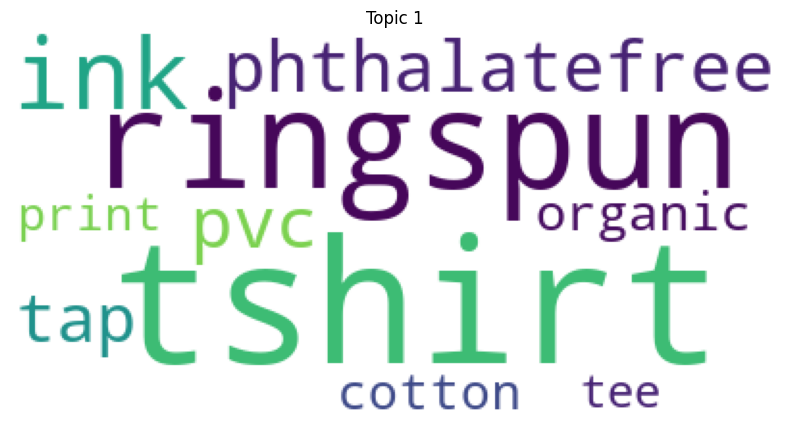

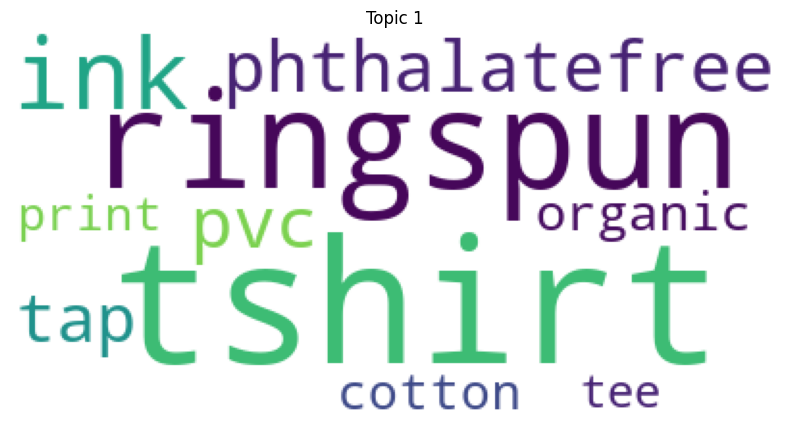

Topic 2 {'merino': np.float64(0.3726983915666543), 'dry': np.float64(0.16586842777831812), 'odor': np.float64(0.15861801223575753), 'layer': np.float64(0.1335868737167302), 'temperature': np.float64(0.11966128807951393), 'beneath': np.float64(0.11694560930898061), 'control': np.float64(0.11553769482403589), 'warm': np.float64(0.1134151330505407), 'cap': np.float64(0.11315878718878551), 'gladiodor': np.float64(0.10737153825176213)}


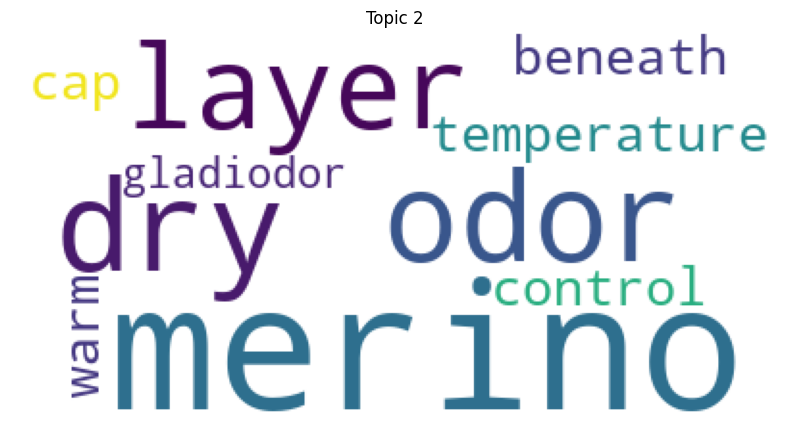

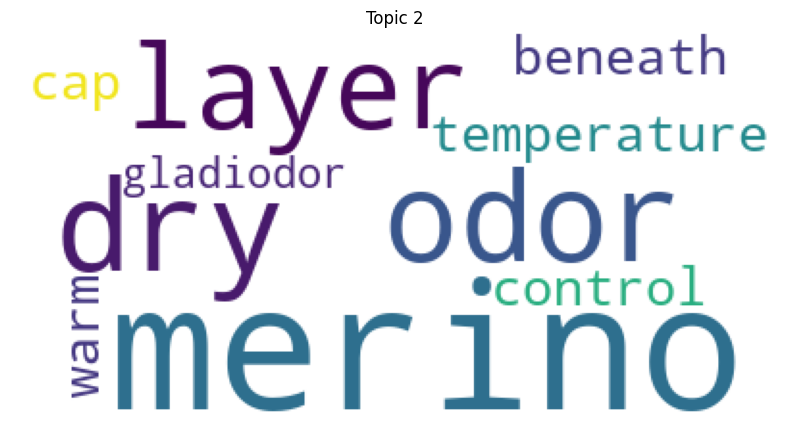

Topic 3 {'merino': np.float64(0.2212708528397409), 'short': np.float64(0.21917020989699584), 'inseam': np.float64(0.1512108108004397), 'pant': np.float64(0.12458690479762345), 'size': np.float64(0.1169279668877067), 'organic': np.float64(0.1125653037277295), 'cotton': np.float64(0.09644413493008779), 'long': np.float64(0.09570693910840004), 'button': np.float64(0.09019972334306962), 'regular': np.float64(0.09014651745417407)}


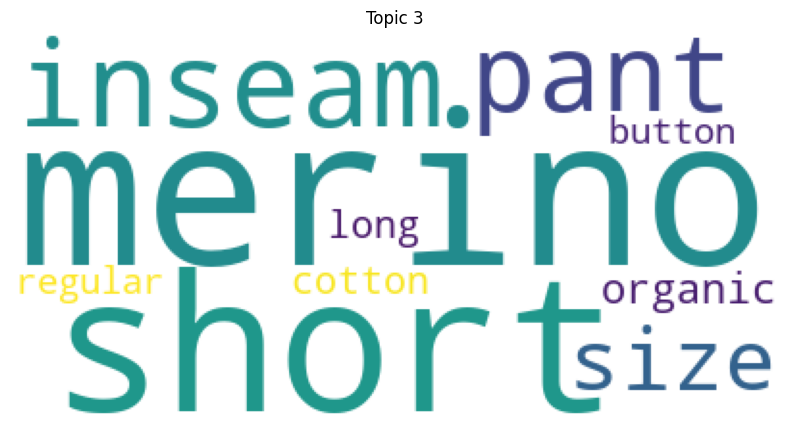

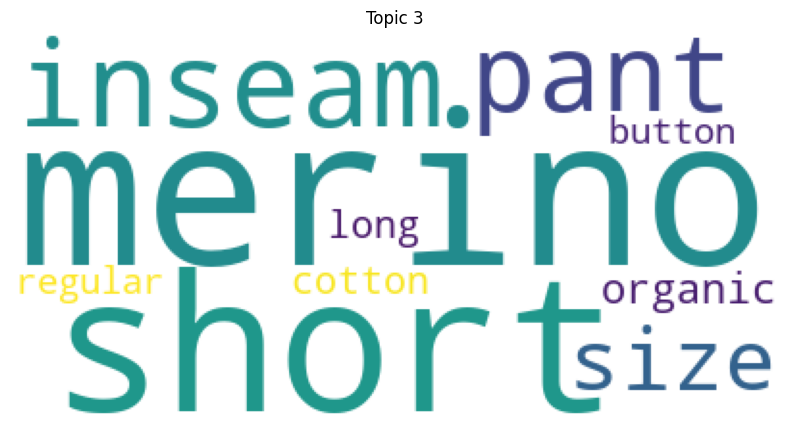

Topic 4 {'merino': np.float64(0.45276889126031494), 'wool': np.float64(0.1287750622392308), 'temperature': np.float64(0.119082483579877), 'machinewash': np.float64(0.0992914319050408), 'slowwash': np.float64(0.0992914319050408), 'lie': np.float64(0.09588816223405563), 'regulate': np.float64(0.09586524014957014), 'away': np.float64(0.09179036299498966), 'resist': np.float64(0.0917646136882341), 'body': np.float64(0.09097193797734797)}


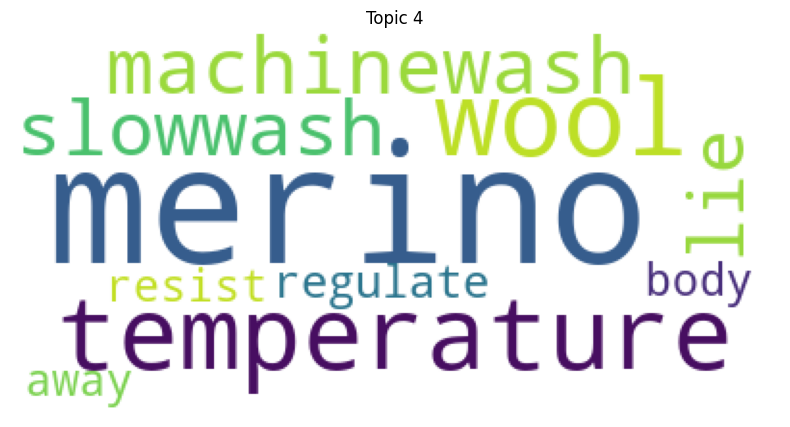

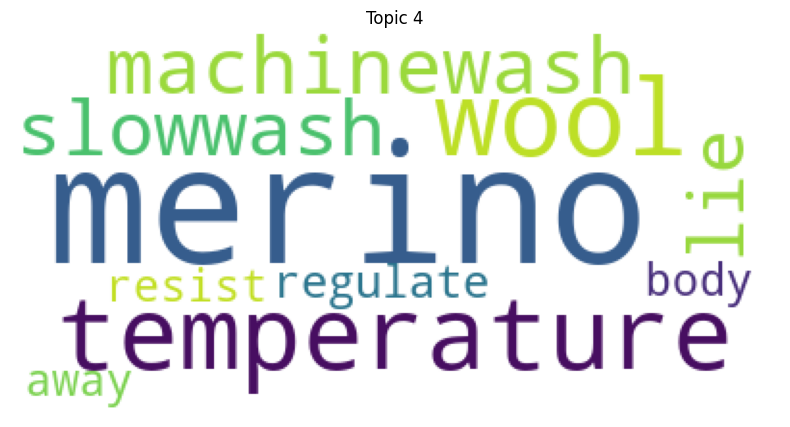

Topic 5 {'spandex': np.float64(0.3093791517527606), 'blend': np.float64(0.304075315870978), 'coverage': np.float64(0.29511690743779284), 'btm': np.float64(0.26333442393790046), 'line': np.float64(0.23947776986019703), 'nylon': np.float64(0.21516754642296215), 'solid': np.float64(0.17563938975311488), 'hip': np.float64(0.15570823852361132), 'scoop': np.float64(0.14790631577255262), 'print': np.float64(0.1288718369658301)}


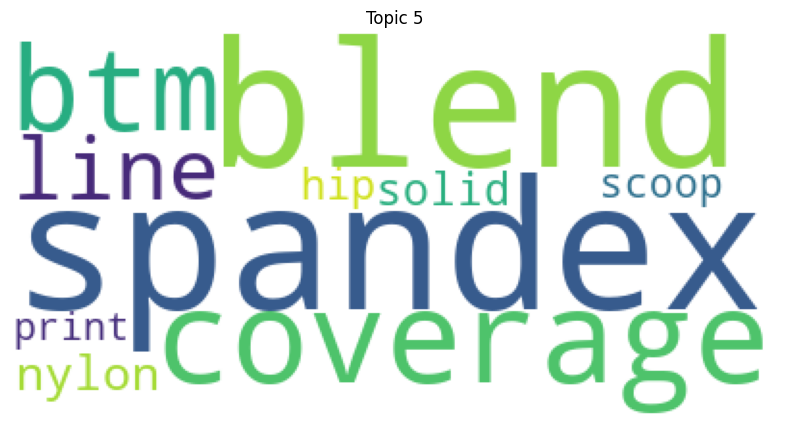

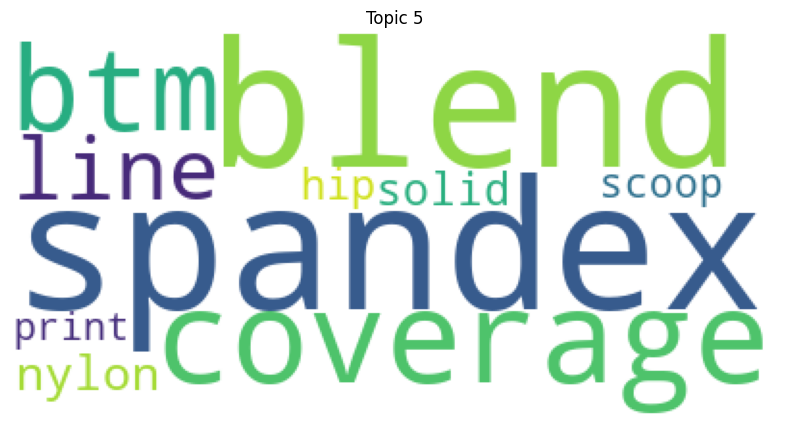

Topic 6 {'photo': np.float64(0.287795927714196), 'outside': np.float64(0.28313897920030306), 'poster': np.float64(0.27558634079363636), 'far': np.float64(0.14679928015403876), 'wall': np.float64(0.14679928015403876), 'exclusively': np.float64(0.14679928015403876), 'excited': np.float64(0.14679928015403876), 'outdoor': np.float64(0.14679928015403876), 'passion': np.float64(0.14679928015403876), 'tribute': np.float64(0.14679928015403876)}


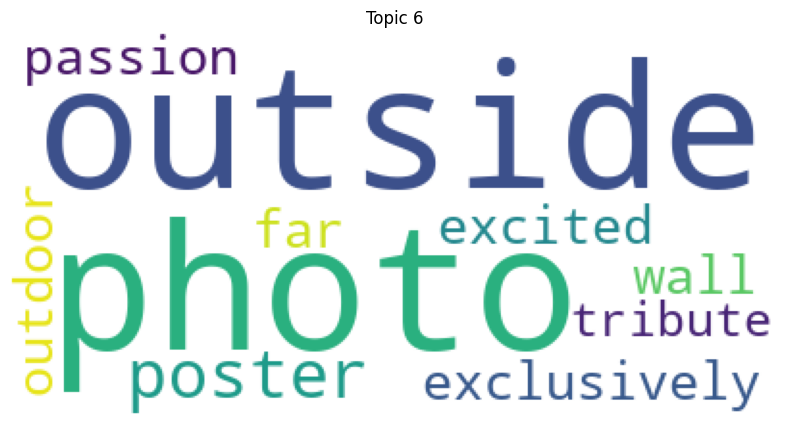

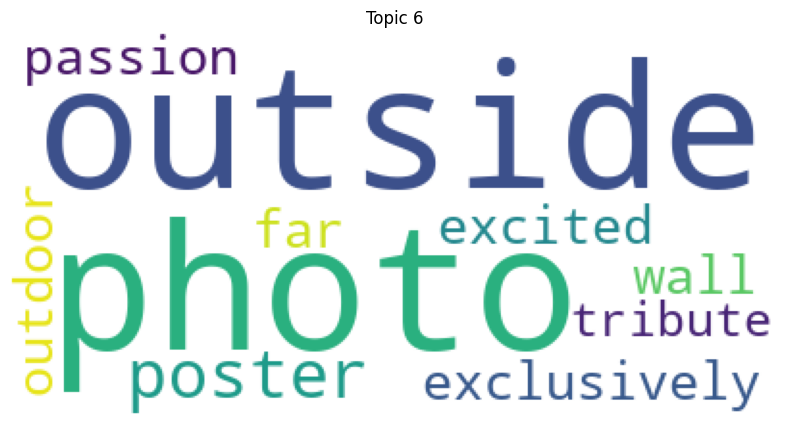

Topic 7 {'shirt': np.float64(0.16921056698210124), 'organic': np.float64(0.16014501870171108), 'fleece': np.float64(0.15611485752892443), 'cuff': np.float64(0.14916785589522055), 'hem': np.float64(0.1475864007087743), 'cotton': np.float64(0.1419198845967137), 'jacket': np.float64(0.13621303568370843), 'handwarmer': np.float64(0.1341761873422993), 'jkt': np.float64(0.1275773694950508), 'dress': np.float64(0.11394885008341736)}


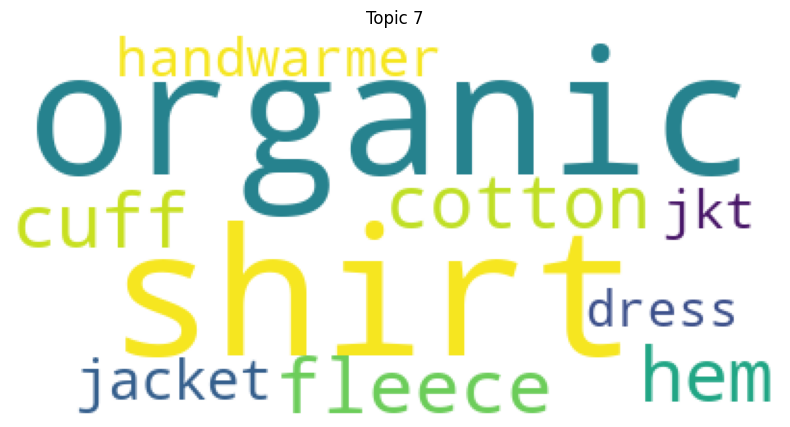

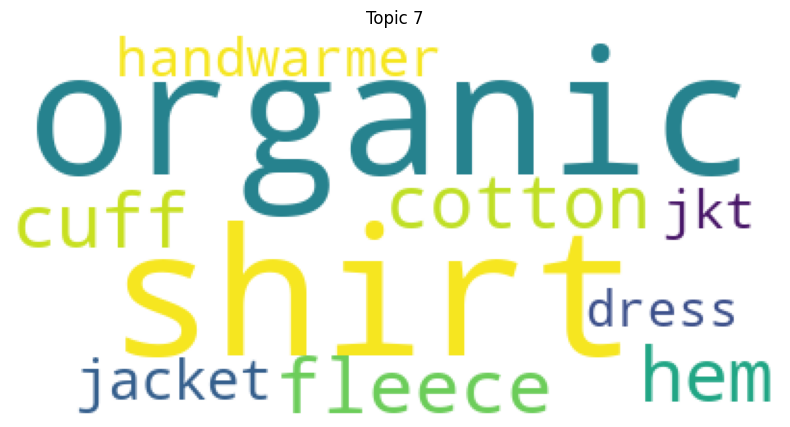

Topic 8 {'pant': np.float64(0.3159243528821004), 'guide': np.float64(0.1147079430398142), 'btm': np.float64(0.11064762282863486), 'tshirt': np.float64(0.10002660787568074), 'gussete': np.float64(0.09679268811850965), 'coverage': np.float64(0.094309473705135), 'loop': np.float64(0.09163707980830553), 'leg': np.float64(0.0913683328645894), 'line': np.float64(0.08999704856292942), 'print': np.float64(0.08989430453184474)}


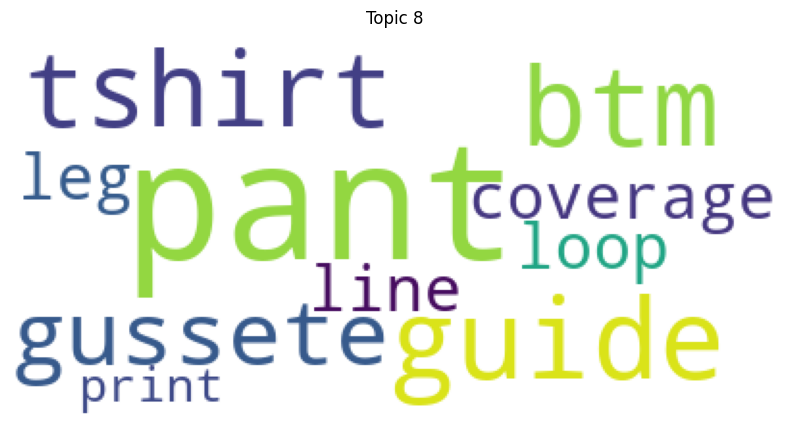

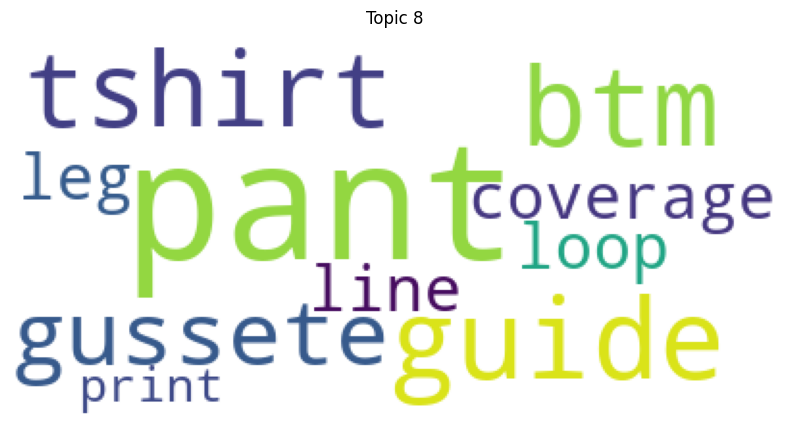

Topic 9 {'sun': np.float64(0.2574398256186201), 'shirt': np.float64(0.21908174354222718), 'upf': np.float64(0.16846116509308254), 'allrecycle': np.float64(0.15906457505716284), 'rashguard': np.float64(0.15421091029804107), 'reflective': np.float64(0.1444717762259225), 'logo': np.float64(0.13494571241386547), 'protection': np.float64(0.12235540553560328), 'vent': np.float64(0.11115360499920653), 'visible': np.float64(0.1088164026539757)}


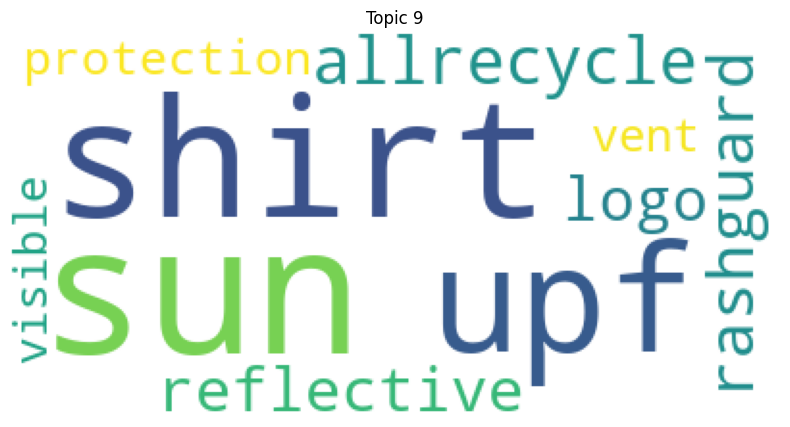

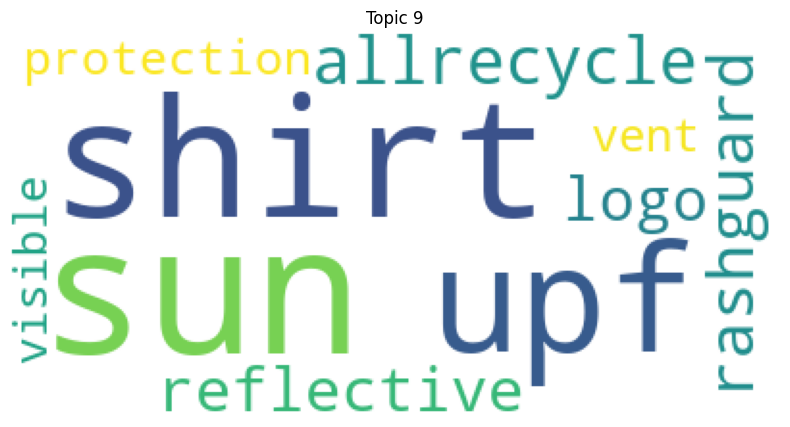

In [9]:
for i, topic in enumerate(topic_terms):
    wc = wordcloud.WordCloud(background_color="white").generate_from_frequencies(topic)

    print(f"Topic {i} {topic}")
    
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {i}")

    filename = f"../images/topic_{i}.png"
    plt.savefig(filename, bbox_inches="tight")

    plt.show()
    
    display(Image(filename))